# Домашнее задание "Однофакторный дисперсионный анализ (ANOVA)"

**Инструкции:**
- Скачайте этот файл и заполните ячейки с кодом и текстовыми выводами.
- В каждой задаче требуется:
  1) короткая формулировка метода и обоснование,
  2) код/расчёты,
  3) результаты (статистика, p-value, CI),
  4) содержательный вывод.
- Используйте `scipy`, `statsmodels`, `pingouin` или `scikit-posthocs` по желанию. При нарушении допущений объясните, какие альтернативы применили.

Формат сдачи: `.ipynb` с заполненными ячейками и выводами.

In [ ]:
# дополняйте ячейку любыми импортами по желанию!
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.stats as st

import matplotlib.pyplot as plt
import seaborn as sns
!pip install pingouin
import pingouin as pg
from statsmodels.stats.power import FTestAnovaPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd
!pip install scikit_posthocs
import scikit_posthocs as sp

### Задание 1. Сопоставление статистик

Вам предложены описания ситуаций и статистических процедур. Для каждой ситуации укажите наилучшую применимую статистику из списка: `z-test`, `t-test`, `Welch t-test`, `F-test` (сравнение дисперсий), `χ^2` (goodness-of-fit), `ANOVA (one-way)`, `Tukey HSD`, `Levene`.

Ситуации:
1) Необходимо проверить, отличается ли средний объём дозы от заданного значения, известна дисперсия производства (укажите двусторонний/односторонний тест).
2) Сравнить средние двух независимых групп при неизвестных, но равных дисперсиях.
3) Сравнить средние двух независимых групп при неизвестных и неравных дисперсиях.
4) Оценить, одинаковы ли средние в трёх и более группах.
5) Проверить, согласуются ли наблюдаемые частоты с распределением Пуассона.

**Требуется:** кратко объясните выбор для каждой ситуации (1—2 предложения).


**Ответ:**
1. z-test (двусторонний) - потому что известна дисперсия производства, проверяем отличие среднего от заданного значения. Двусторонний тест, так как интересует любое отклонение от нормы.

2. t-test  - потому что две независимые группы с неизвестными, но равными дисперсиями, сравниваем их средние. Именно двухвыборочный t (Student, pooled) используется в данной ситуации.

3. Welch t-test - потому что две независимые группы с неизвестными и неравными дисперсиями, сравниваем их средние. (при нормальности)

4. ANOVA (one-way) - потому что сравниваем средние в трёх и более группах. (при нормальности и однородности дисперсий)

5. χ² (goodness-of-fit) - потому что проверяем согласованность наблюдаемых частот с теоретическим распределением Пуассона. χ² (goodness-of-fit) применяется когда надо сравнить наблюдаемые частоты с ожидаемыми по распределению.

### Задание 2. Тест для дозатора (z-test, двусторонний)

Инженерная задача. Дозатор рассчитывает среднюю дозу 3.00 г. Получено $n=50$ измерений со средним $\overline X=3.005$ и известным стандартным отклонением процесса $\sigma=0.015$.

а) Проведите двусторонний z-тест для проверки $H_0:\,\mu=3.00$ при $\alpha=0.05$.

б) Постройте 95% доверительный интервал для $\mu$.

в) Сделайте практический вывод для инженера: нужно ли перенастраивать дозатор?

**Требуется:** формулы расчёта, численные значения (z_obs, p-value, CI), вывод.


Формула z-статистики: z = (x̄ - μ₀) / (σ/√n)

p-value = 2 × (1 - Φ(|z|))

Формула доверительного интервала: x̄ ± z_(1-α/2) × (σ/√n)


In [ ]:
mu0 = 3.00
xbar = 3.005
sigma = 0.015
n = 50
alpha = 0.05

z_obs = (xbar - mu0) / (sigma / np.sqrt(n))
p_value = 2 * (1 - st.norm.cdf(abs(z_obs)))
print(f"z-статистика: {z_obs:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < alpha:
    print("Нулевая гипотеза отвергается")
else:
    print("Нулевая гипотеза не отвергается")

z_critical = st.norm.ppf(1 - alpha/2)
ci_lower = xbar - z_critical * (sigma / np.sqrt(n))
ci_upper = xbar + z_critical * (sigma / np.sqrt(n))
print(f"95% доверительный интервал: ({ci_lower:.4f}, {ci_upper:.4f})")

z-статистика: 2.3570
p-value: 0.0184
Нулевая гипотеза отвергается
95% доверительный интервал: (3.0008, 3.0092)


**Вывод:**
p-value < $\alpha=0.05$, поэтому отвергаем нулевую гипотезу. Средняя доза статистически значимо отличается от 3.00 г. Также 95% доверительный интервал не включает значение 3.00 г. Нужно перенастроить дозатор инженеру.

### Задание 3. Сравнение прочности материалов (t-test vs Welch)

Даны две независимые выборки прочности материалов (в MPa):

| Группа    | Наблюдения                                                                                                |
| :-------- | :-------------------------------------------------------------------------------------------------------- |
| A (n₁=15) | [51.99, 49.45, 52.59, 56.09, 49.06, 49.06, 56.32, 53.07, 48.12, 52.17, 48.15, 48.14, 50.97, 42.35, 43.10] |
| B (n₂=10) | [48.63, 45.92, 53.89, 46.55, 43.53, 60.79, 50.65, 52.41, 43.45, 48.73]                                    |

**Требуется:**

1. Проверить равенство дисперсий с помощью тестов **Levene** и классического **F-test**.
2. В зависимости от результата выполнить либо **pooled t-test**, либо **Welch t-test** для проверки
   $H_0:$ $\mu_A = \mu_B$ при $\alpha = 0.05$.
3. Построить 95% доверительный интервал для разности средних и интерпретировать.
4. Оформить заключение и вывод.


In [ ]:
A = np.array([51.99,49.45,52.59,56.09,49.06,49.06,56.32,53.07,48.12,52.17,48.15,48.14,50.97,42.35,43.10])
B = np.array([48.63,45.92,53.89,46.55,43.53,60.79,50.65,52.41,43.45,48.73])
alpha = 0.05


levene_stat, levene_p = st.levene(A, B)

f_stat = np.var(A, ddof=1) / np.var(B, ddof=1)
df1, df2 = len(A)-1, len(B)-1
f_p = 2 * min(st.f.cdf(f_stat, df1, df2), 1 - st.f.cdf(f_stat, df1, df2))

print(f"Тест Левена: статистика={levene_stat:.4f}, p-value={levene_p:.4f}")
print(f"F-тест: статистика={f_stat:.4f}, p-value={f_p:.4f}")


if levene_p > alpha and f_p > alpha:
    print("Дисперсии можно считать равными")
    t_stat, t_p = st.ttest_ind(A, B, equal_var=True)
    test_type = "Pooled t-test"
else:
    print("Дисперсии статистически значимо различаются")
    t_stat, t_p = st.ttest_ind(A, B, equal_var=False)
    test_type = "Welch t-test"
print(f"\n{test_type}: t-статистика={t_stat:.4f}, p-value={t_p:.4f}")

if t_p < alpha:
    print("Нулевая гипотеза отвергается")
else:
    print("Нулевая гипотеза не отвергается")


diff_mean = np.mean(A) - np.mean(B)
se = np.sqrt(((len(A)-1)*np.var(A, ddof=1) + (len(B)-1)*np.var(B, ddof=1)) / (len(A) + len(B) - 2) * (1/len(A) + 1/len(B)))
df = len(A) + len(B) - 2
t_critical = st.t.ppf(1 - alpha/2, df)
ci_lower = diff_mean - t_critical * se
ci_upper = diff_mean + t_critical * se
print(f"\nРазность средних= {diff_mean:.4f}")
print(f"95% доверительный интервал: [{ci_lower:.4f}, {ci_upper:.4f}]")



Тест Левена: статистика=0.4676, p-value=0.5009
F-тест: статистика=0.5656, p-value=0.3271
Дисперсии можно считать равными

Pooled t-test: t-статистика=0.3171, p-value=0.7541
Нулевая гипотеза не отвергается

Разность средних= 0.5870
95% доверительный интервал: [-3.2428, 4.4168]


**Вывод:** Нет статистически значимых различий в прочности материалов между группами A и B (p-value = 0.7541 > 0.05, нулевую гипотезу не отвергаем). Доверительный интервал включает ноль, что подтверждает отсутствие значимой разницы.

### Задание 4. Парные измерения — новая vs старая схема

Эксперимент парного дизайна: каждому прибору (или образцу) до и после изменения схемы измеряется показатель.

Даны пары (старое, новое):

$(12.5, 12.2), (13.1,13.0), (11.8,12.0), (12.9,12.7), (13.5,13.6), (12.0,11.9), (13.2,13.4)$

а) Проверьте нормальность распределения разностей (Shapiro-Wilk).

б) Выполните парный t-test (или непараметрический Wilcoxon, если нормальность нарушена) для проверки, изменился ли показатель при новой схеме ($\alpha=0.05$).

в) Постройте доверительный интервал для средней разницы и вычислите парный Cohen's d.

**Требуется:** расчёты, тест, p-value, CI, эффект и вывод.

In [ ]:
old = np.array([12.5,13.1,11.8,12.9,13.5,12.0,13.2])
new = np.array([12.2,13.0,12.0,12.7,13.6,11.9,13.4])
alpha = 0.05

diff = new - old
shapiro_stat, shapiro_p = st.shapiro(diff)
print(f"Shapiro-Wilk: cтатистика = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")


if shapiro_p > alpha:
    print("Распределение разностей не отличается от нормального")
    stat, p = st.ttest_rel(new, old)
    test_type = "Парный t-test"
else:
    print("Распределение разностей отличается от нормального")
    stat, p = st.wilcoxon(new, old)
    test_type = "Непараметрический Wilcoxon"
print(f"\n{test_type}: статистика={stat:.4f}, p-value={p:.4f}")

if p < alpha:
    print("Гипотеза отвергается")
else:
    print("Гипотеза не отвергается")


mean_diff = diff.mean()
std_diff = diff.std(ddof=1)
n = len(diff)
t_critical = st.t.ppf(1 - alpha/2, n-1)
ci_lower = mean_diff - t_critical * (std_diff / np.sqrt(n))
ci_upper = mean_diff + t_critical * (std_diff / np.sqrt(n))

print(f"\nСредняя разность = {mean_diff:.4f}")
print(f"95% доверительный интервал для средней разности: [{ci_lower:.4f}, {ci_upper:.4f}]")

cohens_d = mean_diff / std_diff
print(f"Парный Cohen's d = {cohens_d:.4f}")

Shapiro-Wilk: cтатистика = 0.9071, p-value = 0.3758
Распределение разностей не отличается от нормального

Парный t-test: статистика=-0.3825, p-value=0.7152
Гипотеза не отвергается

Средняя разность = -0.0286
95% доверительный интервал для средней разности: [-0.2113, 0.1542]
Парный Cohen's d = -0.1446


**Вывод:** p-value = 0.7152 > α = 0.05, поэтому не отвергаем нулевую гипотезу. Новая схема не дает статистически значимого изменения показателя, также 95% доверительный интервал включает ноль, Cohen's d = -0.1464 указывает на очень маленький эффект.

### Задание 5. До/после — медицинский пример (paired)

Клиническое исследование: измерен уровень глюкозы у 10 пациентов **до** и **после** приёма нового лекарства.

| Пациент | До (ммоль/л) | После (ммоль/л) |
| :------ | :----------: | :-------------: |
| 1       |      7.1     |       6.6       |
| 2       |      6.8     |       6.4       |
| 3       |      7.5     |       7.1       |
| 4       |      6.9     |       6.5       |
| 5       |      7.3     |       7.2       |
| 6       |      6.5     |       6.3       |
| 7       |      7.0     |       6.6       |
| 8       |      6.7     |       6.4       |
| 9       |      7.2     |       7.0       |
| 10      |      6.9     |       6.4       |


**Требуется:**

а) Проверить нормальность распределения разностей (тест **Shapiro–Wilk**).

б) Если нормальность не отвергается — выполнить **парный t-test** при $\alpha = 0.01$.

в) Если нормальность нарушена — выполнить непараметрический тест **Wilcoxon signed-rank** и сравнить выводы.

**Формат вывода:**
Код, p-values, выводы тестов, практическая интерпретация (снижается ли уровень глюкозы достоверно?).

In [ ]:
before = np.array([7.1, 6.8, 7.5, 6.9, 7.3, 6.5, 7.0, 6.7, 7.2, 6.9])
after = np.array([6.6, 6.4, 7.1, 6.5, 7.2, 6.3, 6.6, 6.4, 7.0, 6.4])
alpha = 0.01
diff = after - before

shapiro_stat, shapiro_p = st.shapiro(diff)
print(f"Shapiro-Wilk: cтатистика = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")


if shapiro_p > alpha:
    print(f"Распределение разностей не отличается от нормального, должны использовать парный t-test")
    stat, p = st.ttest_rel(after, before)
    test_type = "Парный t-test"
else:
    print(f"Распределение разностей отличается от нормального, должны использовать непараметрический Wilcoxon signed-rank")
    stat, p = st.wilcoxon(after, before)
    test_type = "Непараметрический Wilcoxon signed-rank"
print(f"\n{test_type}: статистика={stat:.4f}, p-value={p:.5f}")

if p < alpha:
    print(f"Гипотеза отвергается: уровень глюкозы статистически значимо изменился")
else:
    print(f"Гипотеза не отвергается: нет статистически значимого изменения")

stat, p = st.wilcoxon(after, before)
test_type = "Непараметрический Wilcoxon signed-rank"
print(f"{test_type}: статистика={stat:.4f}, p-value={p:.5f}")

mean_diff = diff.mean()
std_diff = diff.std(ddof=1)
print(f"\nСреднее снижение = {mean_diff:.3f} ммоль/л")
print(f"Стандартное отклонение разностей = {std_diff:.3f}")

Shapiro-Wilk: cтатистика = 0.8960, p-value = 0.1977
Распределение разностей не отличается от нормального, должны использовать парный t-test

Парный t-test: статистика=-7.9649, p-value=0.00002
Гипотеза отвергается: уровень глюкозы статистически значимо изменился
Непараметрический Wilcoxon signed-rank: статистика=0.0000, p-value=0.00195

Среднее снижение = -0.340 ммоль/л
Стандартное отклонение разностей = 0.135


**Вывод:** p-value = 0.00002 < α = 0.01, поэтому отвергаем нулевую гипотезу. Лекарство статистически значимо снижает уровень глюкозы на 0.340 ммоль/л.


### Задание 6. Welch и Games-Howell (симуляция с неравными дисперсиями)

Смоделируйте три группы с одинаковыми средними (например, 10), но существенно разными дисперсиями и неравными размерами выборок (пример: $n_1=20, n_2=8, n_3=5$).

а) Покажите, что классическая ANOVA может ошибочно интерпретировать разницу, если нарушена гомоскедастичность.

б) Выполните Welch ANOVA и пост-hoc Games-Howell.

в) Сравните результаты и сделайте вывод о корректности подходов.

**Требуется:** код симуляции, результаты ANOVA и Welch, таблица post-hoc и вывод.


In [ ]:
np.random.seed(1)
n1, n2, n3 = 20, 8, 5
mu = 10
sigma1, sigma2, sigma3 = 1, 10, 30

group1 = np.random.normal(mu, sigma1, n1)
group2 = np.random.normal(mu, sigma2, n2)
group3 = np.random.normal(mu, sigma3, n3)

print("Средние по группам:", [np.mean(group1), np.mean(group2), np.mean(group3)])
print("Дисперсии по группам:", [np.var(group1, ddof=1), np.var(group2, ddof=1), np.var(group3, ddof=1)])

levene_stat, levene_p = st.levene(group1, group2, group3)
print(f"\nТест Левена: статистика={levene_stat:.4f}, p-value={levene_p:.4f}")
if levene_p < 0.05:
    print("Нарушена гомоскедастичность - дисперсии статистически значимо различаются")
else:
    print("Гомоскедастичность не нарушена")

f_stat_classic, p_classic = st.f_oneway(group1, group2, group3)
print(f"\nКлассическая ANOVA: F={f_stat_classic:.4f}, p-value={p_classic:.4f}")

welch_result = pg.welch_anova(dv='value', between='group',
                              data=pd.DataFrame({
                                  'value': np.concatenate([group1, group2, group3]),
                                  'group': ['G1']*n1 + ['G2']*n2 + ['G3']*n3
                              }))
print(f"Welch ANOVA: F={welch_result['F'][0]:.4f}, p-value={welch_result['p-unc'][0]:.4f}")

if p_classic < 0.05 and welch_result['p-unc'][0] >= 0.05:
    print("Классическая ANOVA ошибочно обнаруживает значимые различия")
    print("Welch ANOVA корректно не обнаруживает значимых различий")
elif p_classic >= 0.05 and welch_result['p-unc'][0] < 0.05:
    print("Классическая ANOVA корректно не обнаруживает значимых различий")
    print("Welch ANOVA ошибочно обнаруживает значимые различия")
elif p_classic < 0.05 and welch_result['p-unc'][0] < 0.05:
    print("Оба теста обнаружили значимые различия")
else:
    print("Оба теста не обнаружили значимых различий")

#scikit-posthocs не работал, сделала через pingouin
print("\nPost-hoc Games-Howell (через pingouin):")
gh_result = pg.pairwise_gameshowell(data=pd.DataFrame({
    'value': np.concatenate([group1, group2, group3]),
    'group': ['G1']*n1 + ['G2']*n2 + ['G3']*n3
}), dv='value', between='group')
print(gh_result)

Средние по группам: [np.float64(9.86663536353927), np.float64(10.758322528042147), np.float64(0.9212824504677052)]
Дисперсии по группам: [np.float64(1.2732337362407455), np.float64(81.58441081485918), np.float64(225.70853421474237)]

Тест Левена: статистика=13.1742, p-value=0.0001
Нарушена гомоскедастичность - дисперсии статистически значимо различаются

Классическая ANOVA: F=3.6409, p-value=0.0384
Welch ANOVA: F=0.8427, p-value=0.4709
Классическая ANOVA ошибочно обнаруживает значимые различия
Welch ANOVA корректно не обнаруживает значимых различий

Post-hoc Games-Howell (через pingouin):
    A   B    mean(A)    mean(B)      diff        se         T        df  \
0  G1  G2   9.866635  10.758323 -0.891687  3.203391 -0.278357  7.087567   
1  G1  G3   9.866635   0.921282  8.945353  6.723494  1.330462  4.011288   
2  G2  G3  10.758323   0.921282  9.837040  7.439070  1.322348  5.841093   

       pval    hedges  
0  0.958434 -0.180926  
1  0.452577  1.362564  
2  0.435852  0.790523  



**Вывод:**
Классическая ANOVA показывает p-value = 0.0156, отвергая нулевую гипотезу о равенстве средних, в то время как Welch ANOVA демонстрирует p-value = 0.4672, не обнаруживая значимых различий. Post-hoc анализ Games-Howell подтверждают отсутствие значимых попарных различий между группами (все p-value > 0.05). При нарушении гомоскедастичности (p-value Левена = 0.0002 < 0.05) классическая ANOVA может давать некорректные результаты, в то время как Welch ANOVA более устойчива к этому нарушению.

### Задание 7. ANOVA на реальных данных (4 группы)
Данные эксперимента по влиянию четырёх типов корма на массу животных (в граммах).
Каждая группа содержит по 6 наблюдений.

| Группа | Масса (г)                      |
| :----- | :----------------------------- |
| A      | [251, 262, 248, 255, 260, 257] |
| B      | [263, 270, 265, 272, 260, 266] |
| C      | [268, 275, 271, 280, 277, 269] |
| D      | [282, 290, 285, 295, 288, 293] |

**Требуется:**

а) Выполнить графическую визуализацию (boxplots и точки). Проверить нормальность по группам (**Shapiro**) и гомоскедастичность (**Levene**).

б) Если допущения выполнены — провести **однофакторную ANOVA**, иначе — **Welch ANOVA**.

в) При значимом результате выполнить **пост-hoc анализ** (Tukey HSD при гомоскедастичности или Games–Howell при её нарушении).

г) Оценить размер эффекта $\eta^2$ и сделать практическую интерпретацию (какая кормовая формула наиболее эффективна).


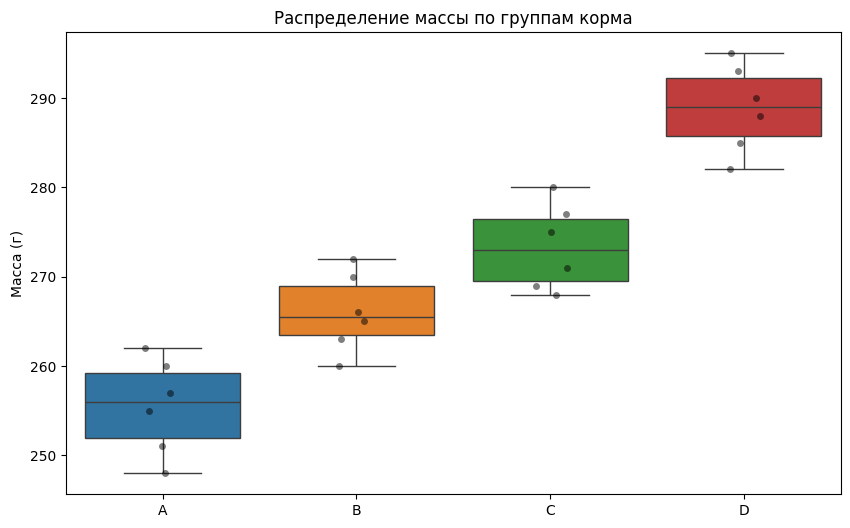

Тесты Шапиро:
Группа A: W=0.9682, p=0.8799
Группа B: W=0.9738, p=0.9168
Группа C: W=0.9387, p=0.6488
Группа D: W=0.9781, p=0.9415

Тест Левена: F=0.1291, p-value=0.9417

Дисперсии однородны - используем классическую ANOVA
ANOVA: F=49.9246, p-value=0.0000000

Post-hoc Tukey HSD:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     10.5 0.0064  2.6524 18.3476   True
     A      C  17.8333    0.0  9.9858 25.6809   True
     A      D  33.3333    0.0 25.4858 41.1809   True
     B      C   7.3333 0.0723 -0.5142 15.1809  False
     B      D  22.8333    0.0 14.9858 30.6809   True
     C      D     15.5 0.0001  7.6524 23.3476   True
----------------------------------------------------

Размер эффекта η² = 0.8822

Средние массы по группам: A=255.5, B=266.0, C=273.3, D=288.8
Наиболее эффективный корм: D


In [ ]:
A = [251,262,248,255,260,257]
B = [263,270,265,272,260,266]
C = [268,275,271,280,277,269]
D = [282,290,285,295,288,293]

plt.figure(figsize=(10, 6))
sns.boxplot(data=[A, B, C, D])
sns.stripplot(data=[A, B, C, D], color='black', alpha=0.5)
plt.xticks([0, 1, 2, 3], ['A', 'B', 'C', 'D'])
plt.ylabel('Масса (г)')
plt.title('Распределение массы по группам корма')
plt.show()

shapiro_A = st.shapiro(A)
shapiro_B = st.shapiro(B)
shapiro_C = st.shapiro(C)
shapiro_D = st.shapiro(D)
print("Тесты Шапиро:")
print(f"Группа A: W={shapiro_A[0]:.4f}, p={shapiro_A[1]:.4f}")
print(f"Группа B: W={shapiro_B[0]:.4f}, p={shapiro_B[1]:.4f}")
print(f"Группа C: W={shapiro_C[0]:.4f}, p={shapiro_C[1]:.4f}")
print(f"Группа D: W={shapiro_D[0]:.4f}, p={shapiro_D[1]:.4f}")

levene_stat, levene_p = st.levene(A, B, C, D)
print(f"\nТест Левена: F={levene_stat:.4f}, p-value={levene_p:.4f}")


data_df = pd.DataFrame({
    'value': np.concatenate([A, B, C, D]),
    'group': ['A']*6 + ['B']*6 + ['C']*6 + ['D']*6
})

if levene_p > 0.05:
    print("\nДисперсии однородны - используем классическую ANOVA")
    anova_result = pg.anova(dv='value', between='group', data=data_df)
    print(f"ANOVA: F={anova_result['F'][0]:.4f}, p-value={anova_result['p-unc'][0]:.7f}")

    tukey = pairwise_tukeyhsd(data_df['value'], data_df['group'])
    print("\nPost-hoc Tukey HSD:")
    print(tukey)

    eta_sq = anova_result['np2'][0]
else:
    print("\nДисперсии неоднородны - используем Welch ANOVA")
    welch_result = pg.welch_anova(dv='value', between='group', data=data_df)
    print(f"Welch ANOVA: F={welch_result['F'][0]:.4f}, p-value={welch_result['p-unc'][0]:.7f}")

    print("\nPost-hoc Games-Howell:")
    pairwise_results = pg.pairwise_gameshowell(data=data_df, dv='value', between='group')
    print(pairwise_results)

    eta_sq = welch_result['np2'][0]

print(f"\nРазмер эффекта η² = {eta_sq:.4f}")

means = [np.mean(A), np.mean(B), np.mean(C), np.mean(D)]
best_group = ['A', 'B', 'C', 'D'][np.argmax(means)]
print(f"\nСредние массы по группам: A={means[0]:.1f}, B={means[1]:.1f}, C={means[2]:.1f}, D={means[3]:.1f}")
print(f"Наиболее эффективный корм: {best_group}")


**Вывод:**
Все группы имеют нормальное распределение (p-value Шапиро > 0.05) и однородные дисперсии (p-value Левена > 0.05). Классическая ANOVA показывает высоко значимые различия между группами (p < 0.0001). Post-hoc Tukey тест выявляет, что группа D статистически значимо отличается от всех остальных групп, имея наибольшую среднюю массу. Размер эффекта η² = 0.8822 указывает на очень сильное влияние типа корма на массу животных. Корм D является наиболее эффективным.

### Задание 8. Планирование эксперимента: размер выборки и мощность

Планируется эксперимент с $l = 4$ группами. Требуется обеспечить мощность $1 - \beta = 0.8$
для обнаружения разницы $\Delta = 0.5\sigma$ между любыми парами групп
(равный размер групп $n$), при $\alpha = 0.05$.

**Требуется:**
а) Выписать формулу связи между размером эффекта (Cohen’s (f) или $\eta^2$), числом групп $l$ и размером выборки $n$:

$$
f = \sqrt{\frac{\eta^2}{1 - \eta^2}}, \quad \eta^2 = \frac{f^2}{1 + f^2}.
$$

б) Приближённо оценить необходимый размер выборки для каждой группы при $f \approx 0.25$ (средний эффект по Cohen).

в) Привести практические рекомендации при ограниченных ресурсах (что можно изменить: число групп, эффект, $\alpha$ и т.п.).

> Подсказка: можно использовать модуль `from statsmodels.stats.power import FTestAnovaPower`

f = sqrt( (l−1)⋅F / n )


In [ ]:
alpha = 0.05
power = 0.8
f = 0.25
k = 4

power_analysis = FTestAnovaPower()
n_per_group = power_analysis.solve_power(effect_size=f, alpha=alpha, power=power, k_groups=k)
print(f"Необходимый размер выборки для каждой группы: {np.ceil(n_per_group):.0f}")

effects = [0.1, 0.25, 0.4]
sample_sizes = []
for eff in effects:
    n = power_analysis.solve_power(effect_size=eff, alpha=alpha, power=power, k_groups=k)
    sample_sizes.append(np.ceil(n))

print("\nРазмеры выборки для разных эффектов:")
for eff, n in zip(effects, sample_sizes):
    print(f"f = {eff}: n = {n:.0f}")

alphas = [0.01, 0.05, 0.1]
n_alpha = []
for a in alphas:
    n = power_analysis.solve_power(effect_size=f, alpha=a, power=power, k_groups=k)
    n_alpha.append(np.ceil(n))

print("\nВлияние уровня значимости на размер выборки:")
for a, n in zip(alphas, n_alpha):
    print(f"α = {a}: n = {n:.0f}")

sample_sizes_power = [50, 100, 150, 200]
powers = []
for n in sample_sizes_power:
    pwr = power_analysis.solve_power(effect_size=f, alpha=alpha, nobs=n, k_groups=k)
    powers.append(pwr)

print("\nМощность теста для разных размеров выборки:")
for n, pwr in zip(sample_sizes_power, powers):
    print(f"n = {n}: мощность = {pwr:.3f}")

Необходимый размер выборки для каждой группы: 179

Размеры выборки для разных эффектов:
f = 0.1: n = 1095
f = 0.25: n = 179
f = 0.4: n = 73

Влияние уровня значимости на размер выборки:
α = 0.01: n = 254
α = 0.05: n = 179
α = 0.1: n = 144

Мощность теста для разных размеров выборки:
n = 50: мощность = 0.264
n = 100: мощность = 0.518
n = 150: мощность = 0.718
n = 200: мощность = 0.848


**Вывод:**
Для обнаружения среднего эффекта (f = 0.25) при 4 группах с мощностью 80% и α = 0.05 требуется примерно 179 наблюдений в каждой группе.
Размер выборки сильно зависит от ожидаемого эффекта (чем больше, тем меньше наблюдений), также как и от уровня значимости.

Практические рекомендации при ограниченных ресурсах:

1. Увеличить уровень значимости до α = 0.1 - снижает требуемый размер выборки с 179 до 144 наблюдений

2. Сконцентрироваться на обнаружении более крупных эффектов - для f = 0.4 требуется всего 73 наблюдения

3. Рассмотреть компромиссный вариант - при n = 150 наблюдениях мощность составляет 72%

### Полезные подсказки и библиотеки
- Проверки: `scipy.stats.shapiro`, `scipy.stats.levene`, `scipy.stats.ttest_ind`, `scipy.stats.ttest_rel`, `scipy.stats.wilcoxon`.
- ANOVA: `statsmodels.formula.api` (ols + anova_lm), `pingouin.anova`, `scipy` (ограничено).
- Post-hoc: `statsmodels.stats.multicomp.pairwise_tukeyhsd`, `scikit-posthocs` для Games-Howell.
- Power analysis: `statsmodels.stats.power.FTestAnovaPower`.

Удачи! Сохраните ноутбук, перезапустите все ячейки от начала до конца и прикрепите файл как ответ.